# Spatial Sorting Analysis

The notebook contains code for analysing the spatial sorting data. 

In [59]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import Delaunay
from scipy.sparse.csgraph import connected_components
from scipy.stats import mode

In [ ]:
#set working directory

os.chdir('')  #add working directory
print(os.getcwd())

In [53]:
# Rearrange data into convenient NumPy arrays for further processing.

pos = np.empty(1, dtype=object)
species_ids = np.empty(1, dtype=object)

filename = 'RB12+TB4.csv' #change filename for each treatment
try:
    df = pd.read_csv(filename)
    df.NO = df.NO.ffill()           
    df.NO = df.NO.astype(np.uint)   
    frame_nos = df.NO.unique() 
    T = len(frame_nos)
    N = 16
    pos = np.full((T, N, 2), np.nan)
    species_ids = np.full((T, N), 'NA')
            
    D = np.full((T, N, N), np.nan)
            
    for i, frame_no in enumerate(frame_nos):
        pos[i, :, 0] = df[df.NO == frame_no].x
        pos[i, :, 1] = df[df.NO == frame_no].y
        species_ids[i, :] = df[df.NO == frame_no]['SPECIES.ID']
        
except FileNotFoundError:
    print(f'File: {filename} not found.')

In [54]:
#processing experimental data to calculate the largest connected component in each frame

largest_comp_rb = np.empty(T)

for t in range(T):
    tri = Delaunay(pos[t])
    ptr, idx = tri.vertex_neighbor_vertices
    neighbour_matrix = np.zeros((N, N), dtype=bool)
        
    for i in range(N):
        neighbour_matrix[i, idx[ptr[i]:ptr[i+1]]] = True
            
    neighbour_matrix_rb = neighbour_matrix[np.ix_(species_ids[t] == 'TB', species_ids[t] == 'TB')] #change species ID to TB 
    _, comp_rb = connected_components(neighbour_matrix_rb)
    largest_comp_rb[t] = np.bincount(comp_rb).max()

# Convert arrays to DataFrame 
df = pd.DataFrame(np.array(largest_comp_rb))
filename = "sorting_data_rb12+tb4_tb.csv" #change output filename for each treatment
df.to_csv(filename, index=False)
print(f"Saved → {filename}")

Saved → sorting_data_rb12+tb4_tb.csv


In [55]:
# Calculate sorting percent for real data

filename = "sorting_data_rb12+tb4_tb.csv" #change filename for each treatment
df = pd.read_csv(filename)

results = {} 
sp = (df== 4).sum()/10 #change value from 8 to 4 for treatment with 12+4 ratio of species
results = sp

# Convert results to a DataFrame
output_df = pd.DataFrame(list(results.items()))

# Save to CSV
output_df.to_csv("sorting_percent_rb12+tb4_tb.csv", index=False) #change filename for each treatment
print(f"Saved → {filename}")

Saved → sorting_data_rb12+tb4_tb.csv


In [56]:
# saving null distribution by randomly shuffling species ID in each frame 

rng = np.random.default_rng()

n_iter = 1000
n_rb = np.sum(species_ids[0] == 'TB') #change species ID to TB 
n_tb = N - n_rb
    
largest_comp_rb_null = np.empty((T, n_iter))
    
for t in range(T):
    tri = Delaunay(pos[t])
    ptr, idx = tri.vertex_neighbor_vertices
    neighbour_matrix = np.zeros((N, N), dtype=bool)
        
    for i in range(N):
        neighbour_matrix[i, idx[ptr[i]:ptr[i+1]]] = True
            
    for i in range(n_iter):
        null_rb = rng.choice(N, n_rb, replace=False)
        neighbour_matrix_rb_null = neighbour_matrix[np.ix_(null_rb, null_rb)]
        _, comp_rb_null = connected_components(neighbour_matrix_rb_null)
        largest_comp_rb_null[t][i] = np.bincount(comp_rb_null).max()
        
filename = 'sorting_data_rb12+tb4_tb_null.csv' #change filename for each treatment
pd.DataFrame(largest_comp_rb_null).to_csv(filename, index=False)
print(f"Saved → {filename}")

Saved → sorting_data_rb12+tb4_tb_null.csv


In [57]:
# Calculate sorting percent for null distribution

results = []  # to store all (col_number, rb) pairs
col_counter = 1  # continuous column numbering

filename = "sorting_data_rb12+tb4_tb_null.csv"  #change filename for each treatment
df = pd.read_csv(filename)

for col in df.columns:
    rb = (df[col] == 4).sum() / 10   #change value from 8 to 4 for treatment with 12+4 ratio of species
    results.append((col_counter, rb))
    col_counter += 1

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Column_Number", "Sorting_Value"])

# Save to CSV
results_df.to_csv("sorting_percent_rb12+tb4_tb_null.csv", index=False) #change filename for each treatment
print(f"Saved → {filename}")

Saved → sorting_data_rb12+tb4_tb_null.csv


Run the above code for the raw data files of each treatment (RB12+TB4.csv, RB8+TB8.csv, RB4+TB12.csv) to calculate the strong sorting per cent in real data and the null distribution of the same.
For RB12+TB4 and RB4+TB12, keep the largest connected component value at 4 and calculate RB values for RB4+TB12 and TB values for RB12+TB4.
For RB8+TB8, keep the largest connected component value as 8 and calculate for both RB and TB.

After preprocessing you will have four data files for real data sorting percent and four data files null distribution.
Use the following code to generate a plot for visualising the comparasion between strong sorting per cent and null distribution; and further calculating the Z-score for the same.

In [ ]:
# Load dataset

df1 = pd.read_csv("sorting_percent_rb4+tb12_rb_null.csv")
df2 = pd.read_csv("sorting_percent_rb8+tb8_rb_null.csv")
df3 = pd.read_csv("sorting_percent_rb8+tb8_tb_null.csv")
df4 = pd.read_csv("sorting_percent_rb12+tb4_tb_null.csv")

df5 = pd.read_csv("sorting_percent_rb4+tb12_rb.csv")
df6 = pd.read_csv("sorting_percent_rb8+tb8_rb.csv")
df7 = pd.read_csv("sorting_percent_rb8+tb8_tb.csv")
df8 = pd.read_csv("sorting_percent_rb12+tb4_tb.csv")

In [60]:
# Combine null data

combined_null = pd.DataFrame({
    "Sorting_Value": pd.concat(
        [df1["Sorting_Value"], df2["Sorting_Value"],
         df3["Sorting_Value"], df4["Sorting_Value"]],
        ignore_index=True
    ),
    "Group": (["RB4+TB12_RB"] * len(df1)) +
             (["RB8+TB8_RB"] * len(df2)) +
             (["RB8+TB8_TB"] * len(df3)) +
             (["RB12+TB4_TB"] * len(df4))
})

In [62]:
# Combine real data

combined_real = pd.DataFrame({
    "Sorting_Value": pd.concat(
        [df5["1"], df6["1"],
         df7["1"], df8["1"]],
        ignore_index=True
    ),
    "Group": (["RB4+TB12_RB"] * len(df5)) +
             (["RB8+TB8_RB"] * len(df6)) +
             (["RB8+TB8_TB"] * len(df7)) +
             (["RB12+TB4_TB"] * len(df8))
})


/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_1666/2023646462.py:42: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/var/folders/yx/fr740nw51gx5ylj1n1z8jp7c0000gn/T/ipykernel_1666/2023646462.py:42: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


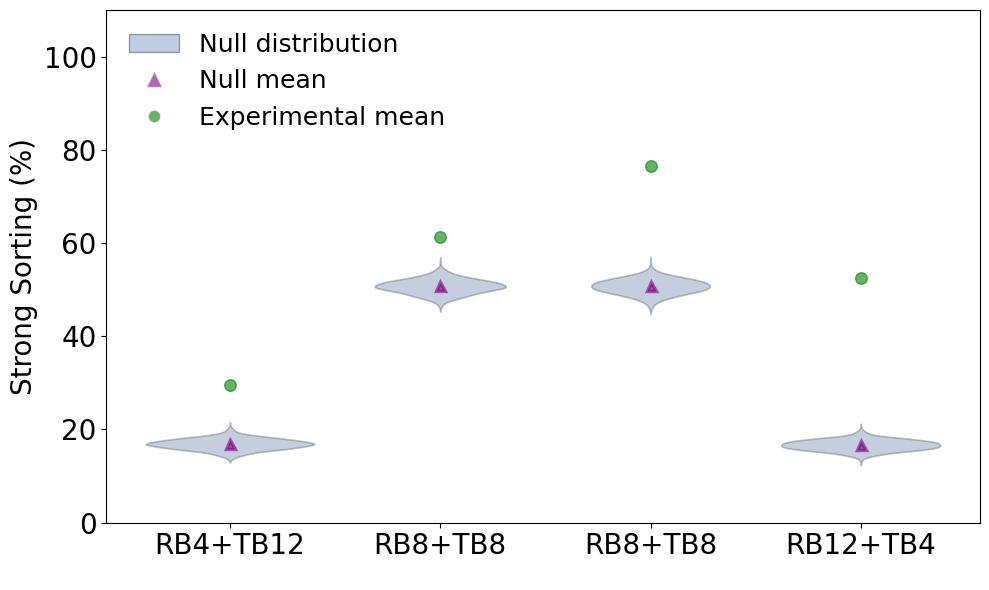


=== Summary Statistics ===

             Null Mean  Null SD  Real Mean  Z-score  p-value
Group                                                       
RB12+TB4_TB    16.6542   1.1331       52.6  31.7225      0.0
RB4+TB12_RB    16.8666   1.1613       29.6  10.9644      0.0
RB8+TB8_RB     50.6963   1.5135       61.3   7.0062      0.0
RB8+TB8_TB     50.6809   1.5685       76.6  16.5246      0.0


In [64]:
# Set labels and order
 
labels = ['RB4+TB12', 'RB8+TB8', 'RB8+TB8', 'RB12+TB4']
x = np.arange(len(labels))

order = [
    "RB4+TB12_RB",
    "RB8+TB8_RB",
    "RB8+TB8_TB",
    "RB12+TB4_TB"
]

# Caculate Z-score

null_means = combined_null.groupby("Group")["Sorting_Value"].mean()
null_sd    = combined_null.groupby("Group")["Sorting_Value"].std()
real_means = combined_real.groupby("Group")["Sorting_Value"].mean()

z_scores = (real_means - null_means) / null_sd
p_values = pd.Series(
    2 * (1 - norm.cdf(np.abs(z_scores))),
    index=z_scores.index
)

# Plotting

plt.figure(figsize=(10, 6))

# Null distribution (smooth violin)
sns.violinplot(
    x="Group", y="Sorting_Value",
    data=combined_null,
    order=order,
    inner=None,
    bw_adjust=1.3,
    linewidth=1.2,
    color="#4C72B0",
    alpha=0.35
)

# Null mean 
sns.pointplot(
    x="Group", y="Sorting_Value",
    data=combined_null,
    order=order,
    estimator=np.mean,
    errorbar=None,
    join=False,
    markers="^",
    scale=1.2,
    linewidth=0.2,
    alpha=.6,
    color="purple",
    zorder=3
)

# Real mean
for i, group in enumerate(order):
    mean_val = real_means.loc[group]

    plt.scatter(
        i, mean_val,
        color="green",
        marker="o",
        s=70,
        alpha=0.6,
        zorder=6
    )


# Legend

legend_elements = [
    Patch(
        facecolor="#4C72B0",
        edgecolor="black",
        alpha=0.35,
        label="Null distribution"
    ),
    Line2D(
        [0], [0],
        marker="^",
        color='w',
        alpha=0.6,
        markerfacecolor="purple",
        markersize=11,
        label="Null mean"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color='w',
        alpha=0.6,
        markerfacecolor="green",
        markersize=9,
        label="Experimental mean"
    )
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=18,
    frameon=False
)

# Cosmetics

plt.ylabel("Strong Sorting (%)", fontsize=20)
plt.xlabel(" ")
plt.ylim(0, 110)
plt.xticks(
    ticks=range(len(order)),
    labels=[
        "RB4+TB12",
        "RB8+TB8",
        "RB8+TB8",
        "RB12+TB4"
    ],
    fontsize=20
)
plt.yticks(fontsize=20)
plt.tight_layout()

# Save & show

plt.savefig("sorting_percent_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary table

summary = pd.DataFrame({
    "Null Mean": null_means,
    "Null SD": null_sd,
    "Real Mean": real_means,
    "Z-score": z_scores,
    "p-value": p_values
})

print("\n=== Summary Statistics ===\n")
print(summary.round(4))
